<a href="https://colab.research.google.com/github/345bc/th-deep-learning/blob/main/BTTuan04_AUTOENCODERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder

Nạp thư viện

In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

Nạp datasets

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()
# Chuan hoa du lieu ve [0,1]
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
# Lam phang du lieu
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Bước 4: Kiểm tra lại kích thước (shape) sau khi xử lý
print("Kích thước tập train:", x_train.shape)
print("Kích thước tập test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập train: (60000, 784)
Kích thước tập test: (10000, 784)


xây dựng mô hình auto encoder

In [3]:
# kich thuoc nén
encode_dim=32

input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encode_dim, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)
encoded_input = keras.Input(shape=(encode_dim,))
decoder_layer = autoencoder.layers[-1] # Lấy tầng Dense(784) cuối cùng của mạng
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

huấn luyện mô hình

In [4]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0125 - loss: 0.2772 - val_accuracy: 0.0134 - val_loss: 0.1910
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0137 - loss: 0.1724 - val_accuracy: 0.0136 - val_loss: 0.1545
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0108 - loss: 0.1451 - val_accuracy: 0.0109 - val_loss: 0.1348
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0105 - loss: 0.1296 - val_accuracy: 0.0124 - val_loss: 0.1223
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0117 - loss: 0.1191 - val_accuracy: 0.0136 - val_loss: 0.1137
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0128 - loss: 0.1120 - val_accuracy: 0.0136 - val_loss: 0.1079
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0125 - loss: 0.1070 - val_accuracy: 0.0118 - val_loss: 0.1036
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0123 - loss: 0.1032 - val_accuracy: 0

dự đoán ảnh

In [6]:
encoder = keras.Model(input_img, encoded)
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


hien thi anh

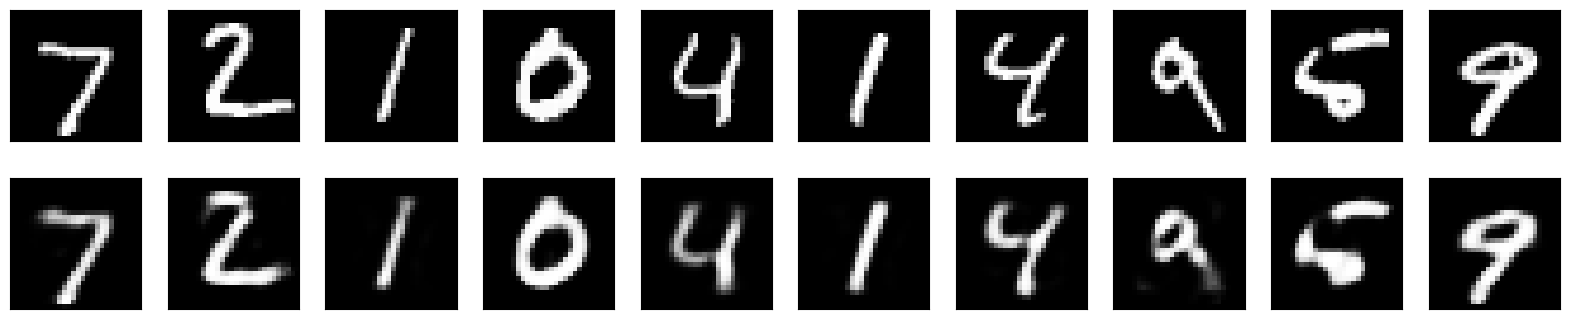

In [7]:
n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()